# Face Detection with Haar Cascades

**Note: This is face *detection* NOT face *recognition*. We are only detecting if a face is in an image, not who the face actually is. That requires deep learning.**

## 1) Load and Display Images

- Step 1: Import necessary packages: numpy, cv2, matplotlib.pyplot
- Step 2: Load grayscale images using cv2.imread() with flag 0
- Step 3: Display images using plt.imshow() with cmap='gray'

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

## Images

In [5]:
withglass = cv2.imread('/content/luffy.jpeg',0)
group = cv2.imread('/content/one piece.jpeg',0)

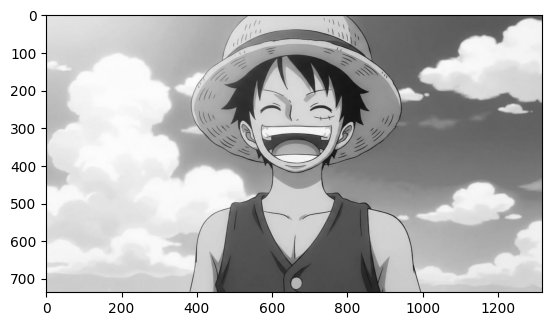

In [31]:
plt.imshow(withglass,cmap='gray')

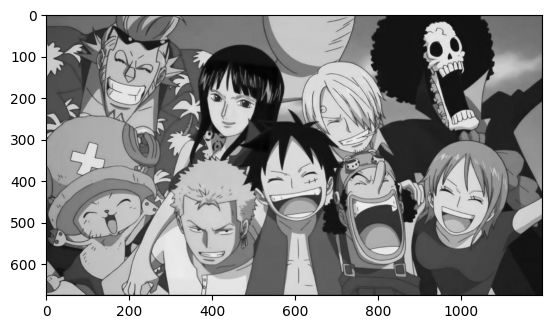

In [32]:
plt.imshow(group,cmap='gray')

## II) Load Haar Cascade Classifiers

- Step 1: Load face and eye cascade XML files

## Face Detection

In [12]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

## III) Perform Face Detection in Images

- Step 1: Define a function detect_face() that copies the input image
- Step 2: Use face_cascade.detectMultiScale() to detect faces
- Step 3: Draw white rectangles around detected faces with thickness 10
- Step 4: Return the processed image with rectangles

In [13]:
def detect_face(img):
    face_img = img.copy()
    face_rects = face_cascade.detectMultiScale(face_img)

    for (x,y,w,h) in face_rects:
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 2)

    return face_img


In [33]:
!wget https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_frontalface_default.xml
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
result = detect_face(withglass)

--2026-09-08 15:53:58--  https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_frontalface_default.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 930127 (908K) [text/plain]
Saving to: ‘haarcascade_frontalface_default.xml.1’

haarcascade_frontal 100%[===================>] 908.33K  --.-KB/s    in 0.006s  

2026-09-08 15:53:58 (138 MB/s) - ‘haarcascade_frontalface_default.xml.1’ saved [930127/930127]



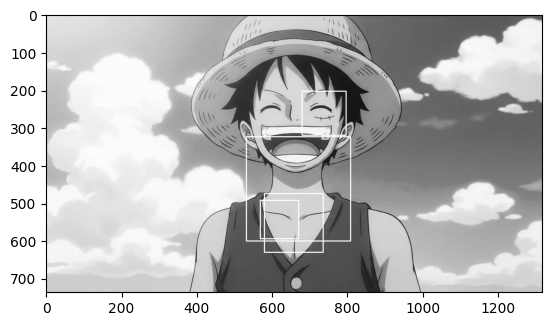

In [19]:
plt.imshow(result,cmap='gray')

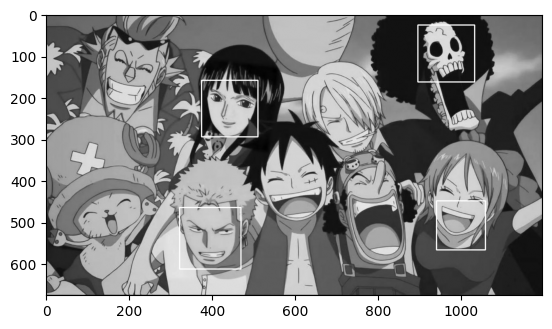

In [34]:
result = detect_face(group)
plt.imshow(result,cmap='gray')

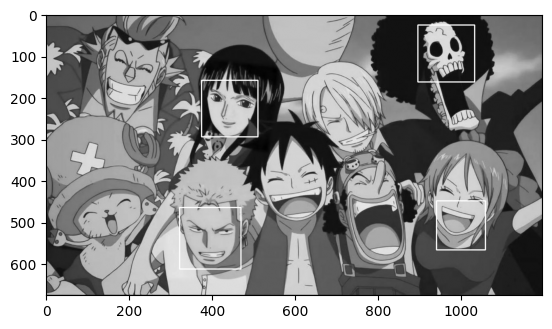

In [36]:
# Gets errors!
result = detect_face(group)
plt.imshow(result,cmap='gray')

In [25]:
def adj_detect_face(img):

    face_img = img.copy()

    face_rects = face_cascade.detectMultiScale(face_img,scaleFactor=1.2, minNeighbors=5)

    for (x,y,w,h) in face_rects:
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 2)

    return face_img

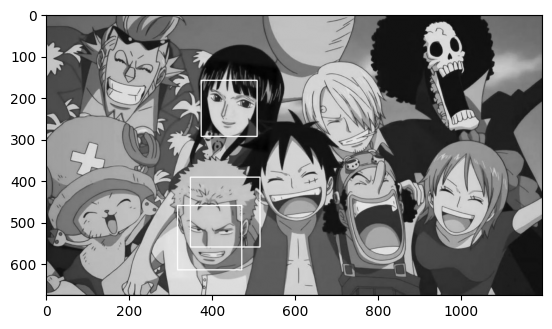

In [37]:
# Doesn't detect the side face.
def adj_detect_face(img):

    face_img = img.copy()

    face_rects = face_cascade.detectMultiScale(face_img,scaleFactor=1.2, minNeighbors=5)

    for (x,y,w,h) in face_rects:
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 2)

    return face_img

result = adj_detect_face(group)
plt.imshow(result,cmap='gray')

## IV) Perform Eye Detection in Images & Display Detection Results on Images

- Step 1: Define a function detect_eyes() that copies the input image
- Step 2: Use eye_cascade.detectMultiScale() to detect eyes
- Step 3: Draw white rectangles around detected eyes with thickness 10
- Step 4: Return the processed image with rectangles
- Step 5: Call detect_face() or detect_eyes() on loaded images
- Step 6: Use plt.imshow() with cmap='gray' to display images with detected regions highlighted

In [27]:
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

In [28]:
def detect_eyes(img):

    face_img = img.copy()

    eyes = eye_cascade.detectMultiScale(face_img)


    for (x,y,w,h) in eyes:
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 2)

    return face_img

--2026-09-08 15:54:04--  https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_eye.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 341406 (333K) [text/plain]
Saving to: ‘haarcascade_eye.xml.1’

haarcascade_eye.xml 100%[===================>] 333.40K  --.-KB/s    in 0.003s  

2026-09-08 15:54:04 (98.6 MB/s) - ‘haarcascade_eye.xml.1’ saved [341406/341406]



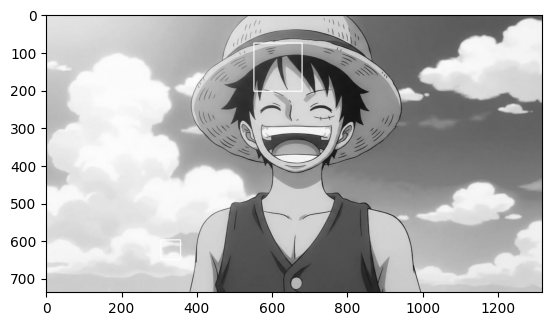

In [38]:
import cv2
!wget https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_eye.xml
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')
result = detect_eyes(withglass)
plt.imshow(result,cmap='gray')

## VI) Perform Face Detection on Real-Time Webcam Video

- Step 1: Capture video from webcam using cv2.VideoCapture(0)
- Step 2: Loop to continuously read frames from webcam
- Step 3: Apply detect_face() function on each frame
- Step 4: Display the video frame with rectangles around detected faces
- Step 5: Exit loop and close windows when ESC key (key code 27) is pressed
- Step 6: Release video capture and destroy all OpenCV windows

In [45]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open video stream or file. Webcam might not be available or accessible in this environment.")
else:
    while True:
        ret, frame = cap.read(0)

        if not ret or frame is None:
            print("Error: Could not read frame from video stream. Exiting.")
            break

        frame = detect_face(frame)

        cv2.imshow('Video Face Detection', frame)

        c = cv2.waitKey(1)
        if c == 27: # ESC key
            break

cap.release()
cv2.destroyAllWindows()

Error: Could not open video stream or file. Webcam might not be available or accessible in this environment.
